# 定理21　包摂半順序臨場感方向性定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> 定理21は **局所的な結果** です。「谷（偏りの中心）のまわりの領域から出発した軌道」だけが対象で、どこから出発しても収束する、とは主張しません。

## 1. 定理21は何を言っているのか

### 原文の主張

定理20は「呼ぶ力が反対勢力に勝てば、象徴の方向へ動く」でした。定理21は、**偏った情報にばかり強い臨場感を注ぐ** と、**しきい値を超えた瞬間に新しい谷が掘れて** 心がそこへ吸い込まれる、という **条件式** を与えます。

* $\mu$：偏った分布（例：訓練データが「ある答え」に偏っている）が作る **臨場感の山**。中心 $x_b$、**丸さ** $m$、**裾の広さ** $r$（$\lvert d\rvert\le r$ の範囲で山は十分に丸い）。
* $S_\mu(x)$：その山の形を表す関数。
* $p$：偏った情報への **実効臨場感**（上限なし）。$\kappa$：臨場感が地形を曲げる強さ。
* 実効地形：$\tilde V_{\mu,p}=V_0-\kappa\,p\,S_\mu$。
* $B,\beta$：**もとの地形 $V_0$** の勾配の上界 $\lVert\nabla V_0\rVert\le B$ と、曲がり方の下界（反り）$\nabla^2V_0\succeq-\beta I$（$U_b$ 上）。
* $U_b=[x_b-r,\;x_b+r]$：偏りの中心のまわりの領域。

臨場感がしきい値

$$
p_{\mathrm{crit}}\;=\;\frac1{\kappa m}\,\max\Bigl\{\beta,\ \frac Br\Bigr\}
$$

を超えると、

$$
p>p_{\mathrm{crit}}\ \Longrightarrow\ \nabla^2\tilde V_{\mu,p}\succeq c\,I\ \ (c=\kappa pm-\beta>0),\qquad \exists!\,x_b^*\in U_b,\qquad \lVert x_b^*-x_b\rVert\le\frac Bc .
$$

つまり $U_b$ の中で **実効地形が強く凸** になり（谷の底がただ一つ）、その底は偏りの中心 $x_b$ から **$B/c$ 以内**。勾配流はそこへ **指数的** に吸い込まれます。

**証明の心。** 偏りの山を引き算した実効地形の曲がり具合（ヘッセ行列）を評価すると、$p$ がしきい値を超えたとき全体が強凸になる。強凸なら最小点は一つで、底のずれも $B/c$ で抑えられる。

**$p_{\mathrm{crit}}$ の中身。** $c=\kappa pm-\beta>0$ には $p>\beta/(\kappa m)$ が要り、底のずれ $B/c$ が裾の広さ $r$ より小さい（谷底が $U_b$ の **内部** に入る）には $\kappa pm-\beta>B/r$ が要ります。しきい値はこの2つを合わせたものです。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 状態 $x$ | 円環 $[0,8)$ 上の「答え」 | `x`、`n = 8` |
| 真の正解 | $x=4$（shift(4)） | `target = 4.0` |
| 偏りの中心 $x_b$ | 訓練データの偏り先 $x=6$（shift(6)） | `bias_center = 6.0` |
| $V_0=0.05\,d^2$ | 基礎評価。真の正解 4 へのわずかな引力 | `V0` |
| $S_\mu=e^{-\frac12 m d^2}$ | 偏りの山（ガウス型の谷） | `S_mu` |
| $\kappa=1,\ m=\tfrac12,\ r=\tfrac12,\ B=\tfrac14,\ \beta=0$ | 定理21の前提の定数 | `kappa, m, r, B, beta` |
| $p_{\mathrm{crit}}=1$ | しきい値 | `p_crit` |
| $x^*(p)$ | $U_b$ 内の唯一の最小点 | `x_star` |

## 2. なぜこれが「定理21の例」と言えるのか

* **状況の類比。** 真の正解は 4 ですが、訓練データが **6 に偏っている**（偏りの谷 $S_\mu$ の中心が 6）という状況です。「$\mathrm{shift}(6)$ が10回中9回出る」ような現象の、**連続で決定論的な鋳型** として作られています。
* **前提を満たす定数を実際に置いた。** 偏りの山 $S_\mu=e^{-d^2/2}$ について、$-S_\mu''=(1-d^2)e^{-d^2/2}\ge m=\tfrac12$ が $\lvert d\rvert\le r=\tfrac12$ で成り立ちます。$V_0=0.05\,d_t^2$（$d_t$ は 4 からの距離）は $V_0''=0.1>0$ なので $\beta=0$、$\lvert V_0'\rvert=\lvert x-4\rvert/10\le B=\tfrac14$（$U_b=[5.5,6.5]$ 上）。こうして (21.2)(21.3) を満たし、$p_{\mathrm{crit}}=\dfrac{\max\{0,\,0.25/0.5\}}{1\cdot0.5}=1$。
* **出発点は $U_b$ の中。** 定理21が保証するのは $U_b$ 内から出発した軌道だけなので、シミュレーションも $U_b$ 内から始めます。

## 3. 基本の準備と定数

In [1]:
# %% 準備
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
import numpy as np
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

n = 8.0  # 円環のサイズ (mod n)
target = 4.0     # 真の正解 shift(4)
bias_center = 6.0  # 訓練データが偏っている先 shift(6)

## 4. モデル（地形・勾配・勾配降下）

In [2]:
# %% モデル
def wrap(x):
    return np.mod(x + n / 2, n) - n / 2  # 最短円環距離用に [-n/2, n/2) に畳む

def V0(x, target=target):
    """基礎評価: 真の正解への浅い引力(まだ globally 強くはない)。"""
    d = wrap(x - target)
    return 0.05 * d**2

def S_mu(x, center=bias_center, m=1.0):
    """臨場感カーネル: center を中心とするガウス的な谷(深さ・鋭さ m)。"""
    d = wrap(x - center)
    return np.exp(-0.5 * m * d**2)

def grad_V0(x, target=target):
    d = wrap(x - target)
    return 0.1 * d

def grad_S(x, center=bias_center, m=1.0):
    d = wrap(x - center)
    return -m * d * np.exp(-0.5 * m * d**2)

def simulate(p, kappa=1.0, m=1.0, x0=5.5, steps=400, dt=0.05):
    x = x0
    traj = [x]
    for _ in range(steps):
        # Vtilde = V0 - kappa * p * S_mu  =>  勾配降下: xdot = -d(Vtilde)/dx
        g = grad_V0(x) - kappa * p * grad_S(x, center=bias_center, m=m)
        x = x - dt * g
        x = np.mod(x, n)
        traj.append(x)
    return np.array(traj)

$\tilde V=V_0-\kappa pS_\mu$ の勾配降下 $x\leftarrow x-dt\,\nabla\tilde V$ です。円環なので位置は mod 8 で折り返し、距離は最短の円環距離（`wrap`）で測ります。

## 5. しきい値 $p_{\mathrm{crit}}$・シミュレーション・可視化

p_crit = 1.000  (Lean: p>1 で U_b 内部に唯一の最小点)


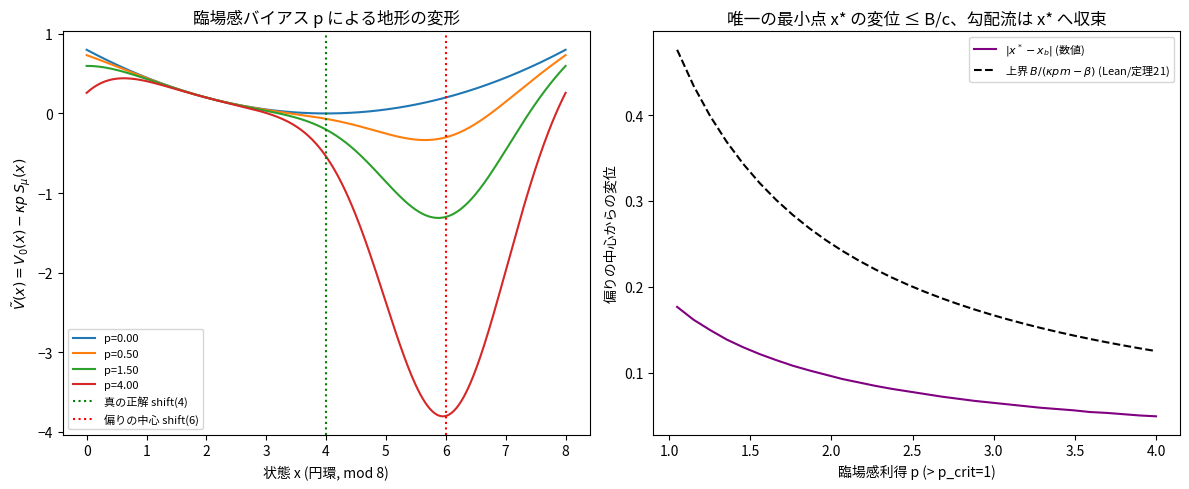

In [3]:
# %% p_crit・シミュレーション・可視化
# Lean 対応: Tomabechi/Examples/Theorem21_GaussianValley.lean (python_valley)
# 定理21の前提 (21.2)(21.3) を満たす定数。U_b=[x_b-r, x_b+r]=[5.5, 6.5]:
#   ガウス核 S=exp(-d²/2) の -S''=(1-d²)e^{-d²/2} ≥ m=1/2 (|d|≤r=1/2 で成立; 旧 m=1, r=1.5 は不成立)
#   V0=0.05 d_t²: V0''=0.1>0 なので beta=0、|V0'|=|x-4|/10 ≤ B=1/4 (U_b 上)
kappa, m, beta, B, r = 1.0, 0.5, 0.0, 0.25, 0.5
p_crit = max(beta, B / r) / (kappa * m)          # = 1
print(f"p_crit = {p_crit:.3f}  (Lean: p>1 で U_b 内部に唯一の最小点)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左図: ポテンシャル形状(p を変えたときの Vtilde)
xs = np.linspace(0, n, 400)
for p in [0.0, p_crit * 0.5, p_crit * 1.5, p_crit * 4]:
    Vtil = V0(xs) - kappa * p * S_mu(xs)
    axes[0].plot(xs, Vtil, label=f"p={p:.2f}")
axes[0].axvline(target, color="green", ls=":", label="真の正解 shift(4)")
axes[0].axvline(bias_center, color="red", ls=":", label="偏りの中心 shift(6)")
axes[0].set_xlabel("状態 x (円環, mod 8)")
axes[0].set_ylabel(r"$\tilde V(x) = V_0(x) - \kappa p\, S_\mu(x)$")
axes[0].set_title("臨場感バイアス p による地形の変形")
axes[0].legend(fontsize=8)

# 右図: p>p_crit で U_b から出発した勾配流が、U_b 内部の唯一の最小点 x*(p) へ収束する
ps = np.linspace(1.05, 4.0, 30)
Ub = np.linspace(bias_center - r, bias_center + r, 2001)
x_star, final_spread, disp_bound = [], [], []
rng = np.random.default_rng(0)
for p in ps:
    Vt = V0(Ub) - kappa * p * S_mu(Ub)
    xs_p = Ub[np.argmin(Vt)]; x_star.append(xs_p)
    finals = [simulate(p, kappa=kappa, x0=x0, steps=3000)[-1] for x0 in rng.uniform(bias_center - r, bias_center + r, 20)]
    final_spread.append(np.max(np.abs(np.array(finals) - xs_p)))
    disp_bound.append(B / (kappa * p * m - beta))                     # |x* - x_b| <= B/c
x_star, final_spread, disp_bound = map(np.array, (x_star, final_spread, disp_bound))

axes[1].plot(ps, np.abs(x_star - bias_center), color="purple", label=r"$|x^*-x_b|$ (数値)")
axes[1].plot(ps, disp_bound, "k--", label=r"上界 $B/(\kappa p m-\beta)$ (Lean/定理21)")
axes[1].set_xlabel("臨場感利得 p (> p_crit=1)")
axes[1].set_ylabel("偏りの中心からの変位")
axes[1].set_title("唯一の最小点 x* の変位 ≤ B/c、勾配流は x* へ収束")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

右の図の計算では、各 $p\in(1,4]$ について、(i) $U_b$ 上で $\tilde V$ が最小になる点 $x^*(p)$ を格子で求め、(ii) $U_b$ 内の乱数 20 点から勾配流を 3000 ステップ走らせて終点を調べ、(iii) 理論上の変位上界 $B/(\kappa pm-\beta)$ を計算します。

## 6. 図を読む

### 左：臨場感 $p$ による地形の変形

縦軸が実効地形 $\tilde V(x)$、横軸が円環上の位置（0〜8）。緑の点線が真の正解 $x=4$、赤の点線が偏りの中心 $x=6$。

* **$p=0$（青）：** 素の地形 $V_0$ だけ。**$x=4$ に浅い谷** があり、最小値は $0$。
* **$p=0.5$（橙）：** すでに **$x\approx5.7$ に谷** ができています（深さ約 $-0.33$）。真の正解 4 付近の谷は消えています。
* **$p=1.5$（緑）：** 谷は $x\approx5.9$ で深さ約 $-1.3$。**$x=4$ は谷底ではなく、6 へ向かう下り坂の途中** になります。
* **$p=4$（赤）：** 谷は $x\approx5.95$ で深さ約 $-3.8$。ほぼ偏りの中心 6 の真下。

つまり、$p$ を上げるほど **偏りの中心 6 に深い谷が掘れ、真の正解 4 の谷は埋もれます**。ここで **注意**：定理21の $p_{\mathrm{crit}}=1$ は「**これを超えれば確実に一意の谷ができる**」ことを保証する **十分条件** のしきい値です。上の図が示すとおり、$p=0.5<p_{\mathrm{crit}}$ でも谷は（このトイでは）できています。**$p<p_{\mathrm{crit}}$ のときに何が起きるかは、定理21は何も主張しません**（このトイでの観察にすぎません）。

### 右：唯一の最小点 $x^*$ の変位と、定理の上界

横軸は $p$（$p_{\mathrm{crit}}=1$ より大きい範囲）、縦軸は偏りの中心 $x_b=6$ からの変位。

* **紫の実線：** 数値で求めた $\lvert x^*-x_b\rvert$。$p=1.05$ で約 $0.18$、$p=4$ で約 $0.05$。$p$ を上げると谷底は $x_b=6$ に **近づきます**。
* **黒の破線：** 定理21の上界 $B/(\kappa pm-\beta)=0.5/p$。$p=1.05$ で約 $0.48$、$p=4$ で $0.125$。
* **紫は全域で黒の下にあります。** これが $\lVert x_b^*-x_b\rVert\le B/c$ の確認です。上界は余裕を見た見積もりなので、実際の変位はそれより小さくなっています。

## 7. 数値確認

In [4]:
# %% 数値確認
print("U_b から出発した勾配流の最終位置と x* の最大差:", final_spread.max())
assert final_spread.max() < 1e-2                         # U_b 内の初期値は x* に収束 (定理21)
assert np.all(np.abs(x_star - bias_center) <= disp_bound + 1e-9)   # 変位境界 ‖x*-x_b‖ ≤ B/(κpm-β)

U_b から出発した勾配流の最終位置と x* の最大差: 0.00023752615076588768


$U_b$ の中の20個の初期値から出発した勾配流の終点は、いずれも $x^*$ との差が最大約 $2.4\times10^{-4}$ 以内で、**全部が同じ唯一の谷底へ収束** します（`assert` は $10^{-2}$ 未満）。もう1つの `assert` は変位の上界 $\lvert x^*-x_b\rvert\le B/(\kappa pm-\beta)$ です。
**この例が確認していないこと：** 出発点が $U_b$ の外、たとえば真の正解 $x=4$ のそばの場合は、定理21の対象外です。

## 8. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **偏った情報に強い臨場感を注ぐと、「その気」になる。** 原文は、定理21を「狭い情報環境が人を『その気』にさせる仕組みの、正確な条件式」と説明します。しきい値を超えた瞬間に新しい谷が掘れ、心はそこへ指数的に吸い込まれます。
* **正解より偏りに落ち着く。** 左の図のように、真の正解（4）にわずかな引力があっても、偏った先（6）に強い臨場感があれば、そちらに落ち着きます。
* **しきい値を知れば防げる。** 原文は「同じ数学が、武器にも盾にもなる」と述べます（整合性確認④）。$p_{\mathrm{crit}}$ を知る者は、谷が掘れる条件を見抜けます。
* **段階的な更新へ。** 定理22は、偏った谷だけでなく、「消さずに包む」更新で高い抽象度へ上がっていく話に進みます。

## 9. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem21_GaussianValley.lean`（`python_valley`）。一般の強凸・勾配流の結果は `Theorem21.lean` 側。

| | 内容 | 状態 |
| --- | --- | --- |
| 前提 (21.2)(21.3) | $r=\tfrac12,\ m=\tfrac12,\ \beta=0,\ B=\tfrac14,\ p_{\mathrm{crit}}=1$ の定数で成立 | 証明済 |
| 結論 | $p>1$ なら $U_b$ 内に **唯一の最小点**、勾配流は **指数収束** | 証明済（**局所**：$U_b$ 内の初期値のみ） |
| 図の数値（$x^*(p)$、20点の収束、$p<1$ の谷の形） | 数値のみ | 未証明 |

* **Lean 監査でパラメータを修正した。** 旧パラメータ（$m=1,\ r=1.5$）は (21.2) を満たしませんでした（$-S''=(1-d^2)e^{-d^2/2}\ge m$ が $\lvert d\rvert\le r$ で成り立たない）。そのため Python を $r=0.5,\ m=0.5,\ B=0.25,\ p_{\mathrm{crit}}=1$ に直しました。また、旧版のスイープは「円環全体の任意の初期値から収束する」と読めたので、$U_b$ 内の初期値に限る形に直しています。
* **$p<p_{\mathrm{crit}}$ の挙動** は、定理21の守備範囲外です。